# Polynomial Linear regression - Implementation
- The entire dataset is used for training as the dataset is very smaller
- Problem statement: To predict the Salary given the Level
- The dependent variable will be Salary and the independent variable will be level
- We train the model using Linear regression and using Polynomial linear regression and then compare the results between them

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../../../../datasets/Position_Salaries.csv")
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


- Retaining only `Level` feature 

In [3]:
X = df.drop(columns = ["Position","Salary"])
y = df["Salary"]
X

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# Training using Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Training using Polynomial Regression
- As polynomial linear regression will need $x_1, x_1^2, x_1^3...$
- To create this first we will need to create a matrix/ dataframe which will contain different powers of the features i.e. 1st column will have $x_1$ the next will have $x_1^2$ and so on
- These polynomial features can be created by using `PolynomialFeatures` 

In [5]:
from sklearn.preprocessing import PolynomialFeatures

# The degree determines the maximum degree that will be considered while creating the polynomial features
polynomial_features = PolynomialFeatures(degree = 2)
X_polynomial = polynomial_features.fit_transform(X)
X_polynomial

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [6]:
linear_regression_polynomial = LinearRegression()
linear_regression_polynomial.fit(X_polynomial, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Visualizing the linear regression results

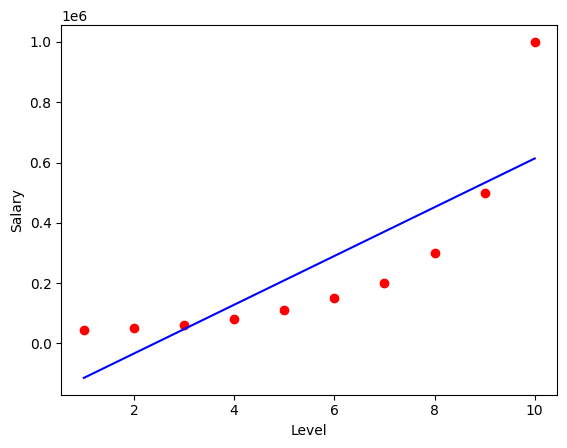

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color = "red")
# Plotting the regression line
plt.plot(X, linear_regression.predict(X), color = "blue")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()


# Visualizing the polynomial linear regression results

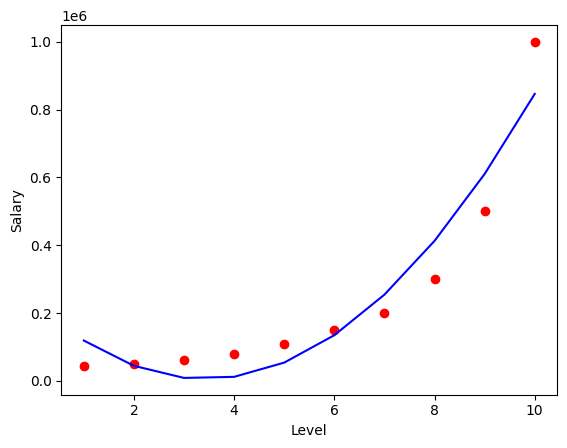

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color = "red")
# Plotting the regression line
plt.plot(X, linear_regression_polynomial.predict(X_polynomial), color = "blue")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()


- You can see that the error is lesser when polynomial linear regression than over linear regression

### Predict the salary when the level = 6.5 using both Linear regression and polynomial linear regression

In [9]:
linear_regression.predict([[6.5]])

/Users/ritumalage/Documents/my_github/Notes/.venv_aiml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([330378.78787879])

In [10]:
linear_regression_polynomial.predict(polynomial_features.transform([[6.5]]))

/Users/ritumalage/Documents/my_github/Notes/.venv_aiml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([189498.10606061])